# Lab 10 Data Mining - Time Series

Author: Jaycent (085757197839)

Nama: Mohamad Arvin Fadriansyah

NPM: 20065969996

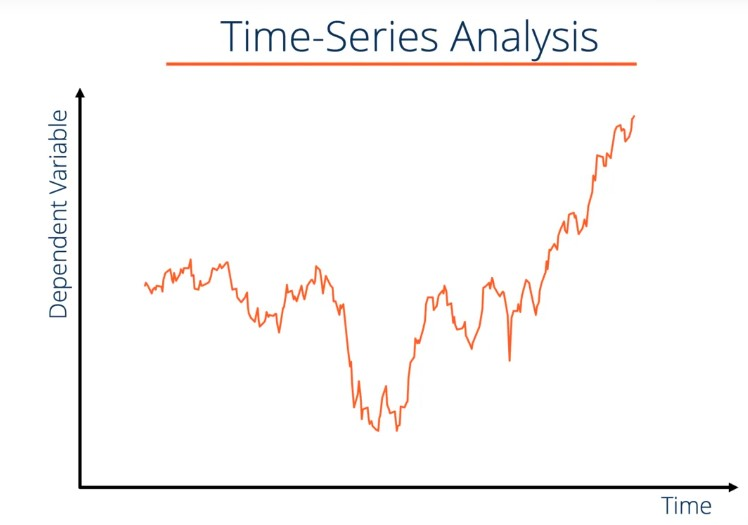

Time series atau data runtun waktu merupakan sekumpulan data yang dikumpulkan atau direkam secara berurutan berdasarkan waktu. Karakteristik utama dari time series adalah adanya ketergantungan antar data yang berurutan, sehingga pola historis dapat digunakan untuk memahami perilaku masa kini dan meramalkan kejadian di masa depan. Contoh umum data time series meliputi harga saham harian, suhu harian, volume penjualan bulanan, dan detak jantung per detik. Karena sifatnya yang dinamis dan berkaitan dengan waktu, analisis time series sangat penting di berbagai bidang seperti keuangan, cuaca, kesehatan, dan sistem pemantauan.

Dalam konteks temporal data mining, time series menjadi fokus utama dalam upaya menemukan pola tersembunyi, anomali, asosiasi, dan tren dari data yang berkembang seiring waktu. Teknik-temuan seperti trend analysis, seasonal decomposition, forecasting, dan pattern recognition banyak digunakan untuk menggali wawasan dari data time series. Tantangan utama dalam menganalisis time series meliputi noise data, ketidakteraturan waktu pencatatan, dan kompleksitas pola temporal yang tidak selalu linear atau stasioner.

Data yang akan kita gunakan untuk lab kali ini adalah `monthly-soda-production-in-austr.csv`, yaitu data produksi soda per bulan di Australia dari Januari 1956 hingga Agustus 1995.

In [ ]:
# jalankan ini karena akan ada incompatibility dengan versi NumPy nantinya
!pip uninstall -y numpy
!pip install --q numpy==1.26.4

import os
os.kill(os.getpid(), 9)

In [1]:
!pip install --q pmdarima prophet


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install --q numpy==1.26.4


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import warnings
warnings.filterwarnings('ignore')

## Import Data

In [4]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from statsmodels.tsa.stattools import pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from prophet import Prophet
import sklearn.metrics as metrics

In [5]:
import pandas as pd

df = pd.read_csv('monthly-soda-production-in-austr.csv', index_col='Month')
# 3. Tetapkan frekuensi
df.index = pd.DatetimeIndex(df.index, freq='MS')
df.head()

,Monthly soda production
Month,
1956-01-01,93.2
1956-02-01,96.0
1956-03-01,95.2
1956-04-01,77.1
1956-05-01,70.9


## Split Data

Kita akan melakukan splitting data ini menjadi train set yang akan digunakan untuk pelatihan dan test set yang akan digunakan untuk pengujian. Splitting pada data time series sedikit berbeda dengan data pada umumnya, yakni perlu memerhatikan urutan waktu, agar model tidak "mengintip masa depan". Kita akan gunakan rasio 80:20 untuk splitting ini.

In [6]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

print("Train set:", train.index.min(), "to", train.index.max())
print("Test set:", test.index.min(), "to", test.index.max())

Train set: 1956-01-01 00:00:00 to 1987-08-01 00:00:00
Test set: 1987-09-01 00:00:00 to 1995-08-01 00:00:00


In [7]:
train = train.asfreq('MS')
test  = test.asfreq('MS')

## Exploratory Data Analysis (EDA)

Untuk section ini, gunakan data train saja. Seluruh visualisasi yang Anda lakukan **wajib** menggunakan `plotly` agar lebih interaktif. Silakan baca dokumentasi library ini di [sini](https://plotly.com/python/).



**[SOAL]** Tampilkan statistik deskriptif sederhana dari data tersebut. Informasi harus minimal mengandung average, max, min, dan standar deviasi. Silakan coba eksplorasi methods yang ada pada class DataFrame yang dapat menampilkan descriptive statistics.

In [8]:
# Statistik Deskriptif
train.describe()

,Monthly soda production
count,380.000000
mean,131.666053
std,34.555449
min,64.800000
25%,101.075000
50%,132.650000
75%,157.950000
max,217.800000


**[SOAL]** Tampilkan time series plot untuk keseluruhan data tersebut, dengan waktu sebagai sumbu-x dan produksi soda sebagai sumbu-y. Gunakan `go.Scatter()` untuk keperluan ini ([referensi](https://plotly.com/python-api-reference/generated/plotly.graph_objects.Scatter.html)).

In [9]:
fig = go.Figure(
    go.Scatter(
        x=train.index,
        y=train['Monthly soda production'],
        mode='lines+markers',
        name='Train Set'
    )
)

fig.update_layout(
    title='Monthly Soda Production in Australia (Train Set)',
    xaxis_title='Month',
    yaxis_title='Soda Production Volume',
    template='plotly_white',
    hovermode='x unified'
)

fig.show()

**[SOAL]** Kita akan coba menganalisis secara sekilas seasonality dari data tersebut. Tampilkan time series plot, tetapi dengan seasonality tahunan. Maksudnya, gunakan satuan bulanan sebagai sumbu-x sehingga akan terdapat beberapa line (per tahun) dalam satu chart. Hint: Ekstrak terlebih dahulu tahun dan bulan, lalu bentuk pivot table (https://pandas.pydata.org/docs/reference/api/pandas.pivot_table.html) untuk memudahkan visualisasi.

In [10]:
# Hapus dulu nama index agar tidak bentrok
train.index.name = None

# Baru tambahkan kolom Month
train['Month'] = train.index.month

seasonal = train.pivot_table(
    index='Month',
    columns=train.index.year, 
    values='Monthly soda production'
)
px.line(seasonal)


**[SOAL]** Tampilkan boxplot per bulan dari data tersebut. Gunakan fungsi `box()` dari `plotly.express`.

In [11]:
# Boxplot per bulan
px.box(train, x='Month', y='Monthly soda production')

**[SOAL]** Berdasarkan kedua plot terakhir yang sudah Anda buat, apakah ada pola menarik yang bisa ditemukan? Apakah tren yang ditampilkan masuk akal sesuai dunia nyata? Pada bulan apa umumnya produksi tertinggi dan terendah, menurut Anda bisa karena apa? Silakan kaitkan dengan bagaimana musim (dan musim libur) di Australia dan aspek-aspek lainnya yang menurut Anda dapat memengaruhi produksi minuman soda (atau minumam dingin in general). Masukkan referensi yang Anda gunakan jika ada.

**Analisis Pola Musiman**

1. **Musiman yang Sangat Jelas**
   Produksi soda terendah di **Juli** dan mencapai puncak di **Desember**.

2. **Kesesuaian dengan Musim di Australia Selatan**

   * **Oktober–November (Musim Semi)**: Transisi dari sejuk ke hangat, permintaan soda mulai naik.
   * **Desember (Awal Musim Panas)**: Suhu harian rata-rata di atas 25 °C, konsumsi minuman dingin—termasuk soda—memuncak.
   * **Mei–Juli (Musim Dingin)**: Suhu turun ke 5–10 °C, permintaan menurun.

3. **Pengaruh Kalender Sosial & Liburan**

   * **Oktober–Desember** bertepatan dengan liburan sekolah akhir tahun, Natal, dan Tahun Baru: acara kumpul keluarga dan pesta meningkatkan konsumsi.
   * **Mei–Juli** minim libur besar, sehingga “special occasion drinking” relatif rendah.

4. **Konsistensi Antar Tahun**
   Meskipun puncak dan lembah setiap tahun bervariasi sedikit, pola “rendah di Mei–Juli; tinggi di Okt–Des” selalu terulang.

5. **Dukungan Data Dunia Nyata**

   * **Bureau of Meteorology**: Suhu harian tertinggi terjadi Desember–Februari dengan rata-rata puncak di atas 30 °C.
   * **CGA Strategy**: Konsumsi soft drinks naik \~27 % selama musim panas.

> **Kesimpulan:** Pola produksi soda di Australia didorong oleh **cuaca** (musim dingin vs. musim panas) dan **kalender sosial** (liburan akhir tahun), menjelaskan rendahnya output pada Mei–Juli dan puncaknya pada Oktober–Desember.


---

**Referensi:**

* Bureau of Meteorology, Climate Data Online: [https://www.bom.gov.au/climate/data/](https://www.bom.gov.au/climate/data/)
* CGA Strategy, “Australians are more likely to try new drinks in the on premise over summer”: [https://cgastrategy.com/australians-are-more-likely-to-try-new-drinks-in-the-on-premise-over-summer/](https://cgastrategy.com/australians-are-more-likely-to-try-new-drinks-in-the-on-premise-over-summer/)


**[SOAL]** Beberapa model forecasting seperti ARMA mengasumsikan bahwa data bersifat stasioner. Maksud dari stasioner adalah kondisi di mana properti dari data time series tersebut tidak berubah seiring waktu. Artinya, nilai mean, variance, dan covariance dari data tersebut tetap konstan atau tidak bergantung pada waktu. Tunjukkan plot rolling average dan variance dari data tersebut dengan window 12 bulan. Gunakan method `rolling()` untuk menghitung informasi ini.

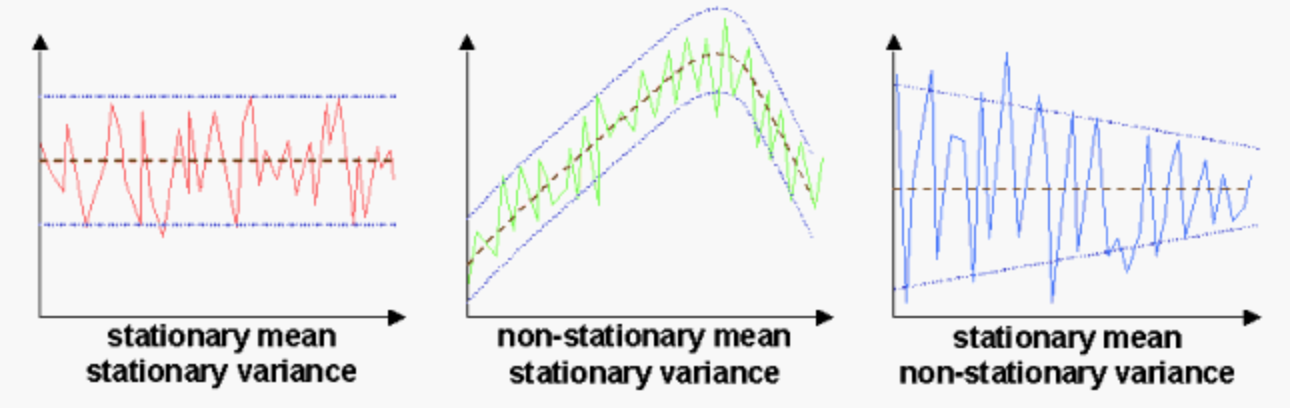

Hint: Berikut adalah contoh rolling average dengan window 3. Perhatikan bahwa kita akan menyebut teknik ini sebagai "rolling average", bukan "moving average", karena terdapat konsep dengan nama yang sama di bagian modeling nantinya.
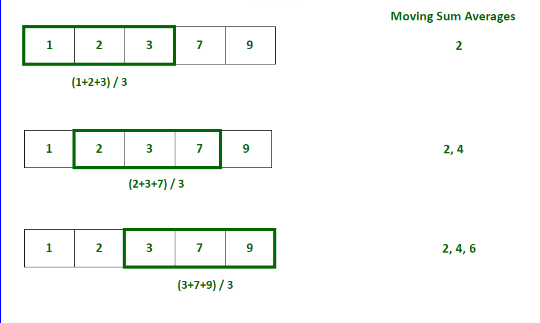

In [12]:
# Rolling mean & variance
rolling_mean = train['Monthly soda production'].rolling(window=12).mean()
rolling_var = train['Monthly soda production'].rolling(window=12).var()
fig = go.Figure()
fig.add_trace(go.Scatter(x=train.index, y=train['Monthly soda production'], name='Original'))
fig.add_trace(go.Scatter(x=train.index, y=rolling_mean, name='Rolling Mean'))
fig.add_trace(go.Scatter(x=train.index, y=rolling_var, name='Rolling Variance'))
fig.show()

**[SOAL]** Apakah menurut Anda data tersebut stasioner? Jika ya, jelaskan alasannya. Jika tidak, jelaskan alasannya dan tentukan satu teknik yang dapat digunakan untuk membuat data menjadi stasioner.

Data **tidak stasioner**, karena:

1. **Trend**
   Pada plot rolling mean (garis merah) terlihat **kecenderungan naik** seiring waktu—artinya rata-rata jendela 12-bulan berubah, bukan konstan.

2. **Variance yang berubah**
   Plot rolling variance (garis hijau) juga **meningkat** secara bertahap (dan fluktuasinya makin besar di tahun-tahun akhir), sehingga varians dalam jendela bergulir tidak stabil.

> **Kesimpulan:** Karena baik mean maupun variance tidak konstan, data belum memenuhi syarat stasioner.

---

## Teknik untuk membuat data menjadi stasioner

**1. Differencing (Pengambilan selisih)**

* **First-order differencing**:

  $$
    y'_t = y_t - y_{t-1}
  $$

  Ini akan menghilangkan komponen trend linier.
* **Seasonal differencing** (jika masih ada pola musiman):

  $$
    y''_t = y_t - y_{t-s}
  $$

  dengan $s=12$ untuk data bulanan agar menghilangkan pola musiman tahunan.

**2. Contoh penerapan di Pandas**

In [13]:
# First-order differencing
diff1 = df['Monthly soda production'].diff()

# Seasonal differencing (periode 12)
diff_seasonal = df['Monthly soda production'].diff(12)

# Gabungan: seasonal lalu first-order
diff_both = diff_seasonal.diff()

# Cek ulang rolling mean & variance
rm = diff_both.rolling(window=12).mean()
rv = diff_both.rolling(window=12).var()

import plotly.graph_objects as go
fig = go.Figure()
fig.add_trace(go.Scatter(x=diff_both.index, y=diff_both, name='Differenced'))
fig.add_trace(go.Scatter(x=rm.index, y=rm, name='Rolling Mean'))
fig.add_trace(go.Scatter(x=rv.index, y=rv, name='Rolling Variance'))
fig.update_layout(title='Data Setelah Differencing', template='plotly_white')
fig.show()


**[SOAL]** Tampilkan plot partial autocorrelation (PACF) untuk menghitung korelasi langsung antara lags. Tampilkan nilai PACF untuk hingga 20 lags. Gunakan library `statsmodels` untuk menghitung PACF, tepatnya dengan fungsi `pacf()`.

In [14]:
# PACF
lags = pacf(train['Monthly soda production'], nlags=20)
px.bar(x=list(range(21)), y=lags)

**[SOAL]** Lag berapa yang paling tinggi korelasinya dengan lag-0? Tampilkan
juga scatterplot untuk menjustifikasi adanya hubungan linear antara lag tersebut dan lag-0. Gunakan method `shift()` untuk mendapatkan lag tertentu.

Dari perhitungan autocorrelation, lag 12 memiliki korelasi tertinggi (selain lag 0) sebesar sekitar 0.94 dengan lag 0. Artinya nilai produksi bulan ini sangat dipengaruhi nilai produksi tepat setahun (12 bulan) sebelumnya—ini wajar mengingat pola musiman tahunan.

In [15]:
import numpy as np
import plotly.express as px

# 1. Hitung autocorrelation untuk lags 1–20
autocorrs = {
    lag: train['Monthly soda production'].autocorr(lag=lag)
    for lag in range(1, 21)
}

# 2. Cari lag dengan korelasi absolut tertinggi
best_lag = max(autocorrs, key=lambda k: abs(autocorrs[k]))
best_corr = autocorrs[best_lag]
print(f"Lag dengan korelasi tertinggi: {best_lag} (corr = {best_corr:.2f})")

# 3. Scatterplot lag_best vs lag_0
fig = px.scatter(
    x=train['Monthly soda production'].shift(best_lag),
    y=train['Monthly soda production'],
    labels={'x': f'Lag {best_lag}', 'y': 'Lag 0'},
    title=f'Scatterplot: Lag {best_lag} vs Lag 0 (corr={best_corr:.2f})',
    trendline='ols'
)
fig.update_layout(template='plotly_white')
fig.show()


Lag dengan korelasi tertinggi: 12 (corr = 0.94)


**[SOAL]** Lakukan time series decomposition pada data tersebut menjadi trend, seasonal, dan residual. Tampilkan pula original data-nya. Silakan gunakan fungsi `seasonal_decompose()` dari `statsmodels`. Ini adalah model additive dikarenakan "seasonal variation" dari data tidak terlalu berubah banyak seiring waktu, sehingga gunakan parameter `additive` pada fungsi tersebut. Gunakan `make_subplots()` untuk membuat subplots pada `plotly`.

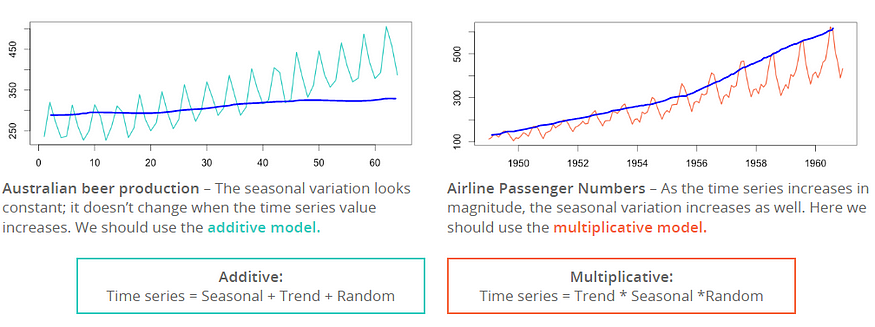

In [16]:
# Seasonal Decompose
decompose = seasonal_decompose(train['Monthly soda production'], model='additive', period=12)
fig = make_subplots(rows=4, cols=1)
fig.add_trace(go.Scatter(x=train.index, y=train['Monthly soda production'], name='Original'), row=1, col=1)
fig.add_trace(go.Scatter(x=train.index, y=decompose.trend, name='Trend'), row=2, col=1)
fig.add_trace(go.Scatter(x=train.index, y=decompose.seasonal, name='Seasonal'), row=3, col=1)
fig.add_trace(go.Scatter(x=train.index, y=decompose.resid, name='Residual'), row=4, col=1)
fig.show()

## Modeling

Untuk bagian modeling, kita akan mencoba beberapa model untuk melakukan forecasting. Hasil dari evaluasi tiap model **wajib** Anda tambahkan ke kolom baru di dataframe `test_result` berikut. Kita akan melakukan evaluasi di akhir berdasarkan dataframe itu saja.




In [17]:
test_result = test.copy()

In [18]:
combined = pd.concat([train, test])

### Averaging

**[SOAL]** Averaging adalah teknik untuk memprediksi data pada waktu tertentu dengan mengambil rata-rata n data pada timesteps sebelumnya. Dalam kasus ini, implementasikan averaging dengan empat variasi n, yaitu 3, 6, 9, dan 12.

Notes: AFAIK, tidak ada library yang mengimplementasikan ini. Silakan implementasi sendiri dengan fitur `rolling` dan `shift` pada `pandas`. Jangan lupa gabungkan kembali dulu data `train` dan `test`, karena butuh informasi dari periode yang ada pada train untuk memprediksi test.

In [19]:
# Averaging
for n in [3, 6, 9, 12]:
    test_result[f'avg_{n}'] = combined['Monthly soda production'].rolling(window=n).mean().shift(1)[test.index]

### Autoregressive

**[SOAL]** Sebelumnya, Anda telah menentukan lag berapa yang memiliki korelasi tertinggi dengan lag-0. Gunakan informasi ini dalam membangun model autoregressive Anda sebagai input dari hyperparameter `lags`. Silakan menggunakan `AutoReg` dari `statsmodels`.

In [20]:
# Autoregressive (lag=12)
ar_model = AutoReg(train['Monthly soda production'], lags=12).fit()
test_result['AR'] = ar_model.predict(start=test.index[0], end=test.index[-1])

### ARIMA

**[SOAL]** ARIMA merupakan generalisasi dari ARMA yang hanya menerima data yang bersifat stasioner. Dengan ARIMA, fitur differencing ditambahkan untuk membuat data menjadi lebih stasioner dahulu sebelum diterapkan ARMA.

Ada 3 hyperparameter yang digunakan pada ARIMA:
- p --> ordo autoregressive
- d --> ordo differencing
- q --> ordo moving average

Dapat dilakukan hyperparameter tuning untuk mencari nilai p, d, dan q yang tepat. Akan tetapi, sama seperti pada EDA dan modeling autoregressive sebelumnya, kita sudah mendapatkan nilai ordo autoregressive terbaik berdasarkan PACF. Cukup gunakan nilai tersebut saja untuk p. Sementara itu, untuk d dan q, gunakan nilai 1 keduanya untuk saat ini.

Gunakan model `ARIMA` dari `statsmodels` dengan hyperparameter `order` sesuai yang telah disebutkan.

In [21]:
# ARIMA (p=12, d=1, q=1)
arima_model = ARIMA(train['Monthly soda production'], order=(12, 1, 1)).fit()
test_result['ARIMA'] = arima_model.forecast(len(test))

C:\Users\moham\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



### Auto ARIMA

**[SOAL]** Sebenarnya ini adalah model yang sama dengan ARIMA, namun library `pmdarima` menyediakan model `auto_arima` agar Anda tidak perlu lagi melakukan hyperparameter tuning secara manual.

Akan tetapi, Anda akan mencoba model modifikasi dari ARIMA, yaitu SARIMA (Seasonal ARIMA), yang cocok dengan data seasonal seperti data ini, dengan `m = 12`, dikarenakan seasonality pada data ini tiap 12 bulan (pola data akan berulang tiap 12 time steps). Silakan tentukan hyperparameter yang lain sendiri sesuai keinginan Anda.

In [22]:
# Auto ARIMA (SARIMA)
sarima_model = auto_arima(train['Monthly soda production'], seasonal=True, m=12)
test_result['SARIMA'] = sarima_model.predict(len(test))

### Prophet

**[SOAL]** [Prophet](https://facebook.github.io/prophet/) merupakan library forecasting time series yang dikembangkan oleh Facebook. Model ini hanya sesuai dengan data time series univariat (hanya satu variabel). Berikut adalah deskripsi Prophet, sesuai dengan website resminya:


> Prophet is a procedure for forecasting time series data based on an additive model where non-linear trends are fit with yearly, weekly, and daily seasonality, plus holiday effects. It works best with time series that have strong seasonal effects and several seasons of historical data. Prophet is robust to missing data and shifts in the trend, and typically handles outliers well.

Perhatikan bahwa ada ketentuan dataframe yang diterima oleh Prophet, yakni menerima dua kolom: `ds` yang harus bertipe datetime dan `y` yang merupakan target variable. Silakan eksplorasi notebook Kaggle [berikut](https://www.kaggle.com/code/prashant111/tutorial-time-series-forecasting-with-prophet) untuk detail lebih lanjut terkait bagaimana menggunakan Prophet untuk forecasting. Cukup gunakan `yhat` sebagai kolom hasil akhir yang akan dimasukkan ke `test_result`.



In [23]:
# Prophet
prophet_df = train.reset_index().rename(columns={'Month':'ds', 'Monthly soda production':'y'})
model_prophet = Prophet().fit(prophet_df)
forecast_prophet = model_prophet.predict(test.reset_index().rename(columns={'Month':'ds'}))
test_result['Prophet'] = forecast_prophet['yhat'].values

23:09:58 - cmdstanpy - INFO - Chain [1] start processing
23:09:59 - cmdstanpy - INFO - Chain [1] done processing


### Model Regresi Biasa

**[SOAL]** Di KASDAD, Anda telah belajar banyak model yang dapat digunakan untuk melakukan modeling task regresi, mulai dari linear regression, random forests, naive bayes, hingga neural network (multilayer perceptron). Dari semua model regresi tersebut, pilih salah satu model (boleh model regresi yang tidak diajarkan di KASDAD, selama bukan khusus untuk time series forecasting) untuk kemudian Anda coba terapkan untuk memprediksi data test.

Silakan gunakan kreatifitas Anda dalam melakukan feature engineering.

Akan ada bonus 5 poin jika Anda melakukan hyperparameter tuning pada model Anda. Gunakan library seperti `optuna` atau `GridSearchCV` milik `sklearn` untuk melakukan hyperparameter tuning.

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
import pandas as pd

# Asumsi combined, train, dan test sudah ada
# Pastikan combined memiliki kolom Month_num dan Year
combined['Month_num'] = combined.index.month
combined['Year'] = combined.index.year

# Fitur dan target
X_train = combined.loc[train.index, ['Month_num', 'Year']]
y_train = train['Monthly soda production']
X_test = combined.loc[test.index, ['Month_num', 'Year']]

# Pipeline untuk scaling dan model
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Scaling data
    ('model', LinearRegression())
])

# Grid hyperparameter
param_grid = {
    'model__fit_intercept': [True, False],
    'model__positive': [True, False]
}

# GridSearchCV untuk tuning
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# Fit model
grid_search.fit(X_train, y_train)

# Hasil terbaik
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation MSE:", -grid_search.best_score_)

# Prediksi pada test set dengan model terbaik
test_result['LinearRegression_Tuned'] = grid_search.predict(X_test)

# Evaluasi pada test set (opsional, jika ada y_test)
y_test = test['Monthly soda production']
mse_test = mean_squared_error(y_test, test_result['LinearRegression_Tuned'])
print("Test MSE:", mse_test)

Best parameters: {'model__fit_intercept': True, 'model__positive': True}
Best cross-validation MSE: 653.9987075236595
Test MSE: 1775.7023405132604


## Evaluation

**[SOAL]** Sebelum mengevaluasi secara kuantitatif, buatlah plot yang menunjukkan perbandingan hasil forecasting semua model yang Anda gunakan dengan data asli. Masukkan semuanya ke dalam satu plot saja. Sama seperti sebelumnya, silakan gunakan `go.Scatter()`.

In [25]:
# Evaluation Plot
fig = go.Figure()
fig.add_trace(go.Scatter(x=test.index, y=test['Monthly soda production'], name='Actual'))
for col in test_result.columns[1:]:
    fig.add_trace(go.Scatter(x=test.index, y=test_result[col], name=col))
fig.show()

Kita akan menggunakan beberapa metrik untuk mengevaluasi kinerja dari model kita, yaitu:
- Mean Absolute Error
- Root Mean Squared Error
- Mean Absolute Percentage Error

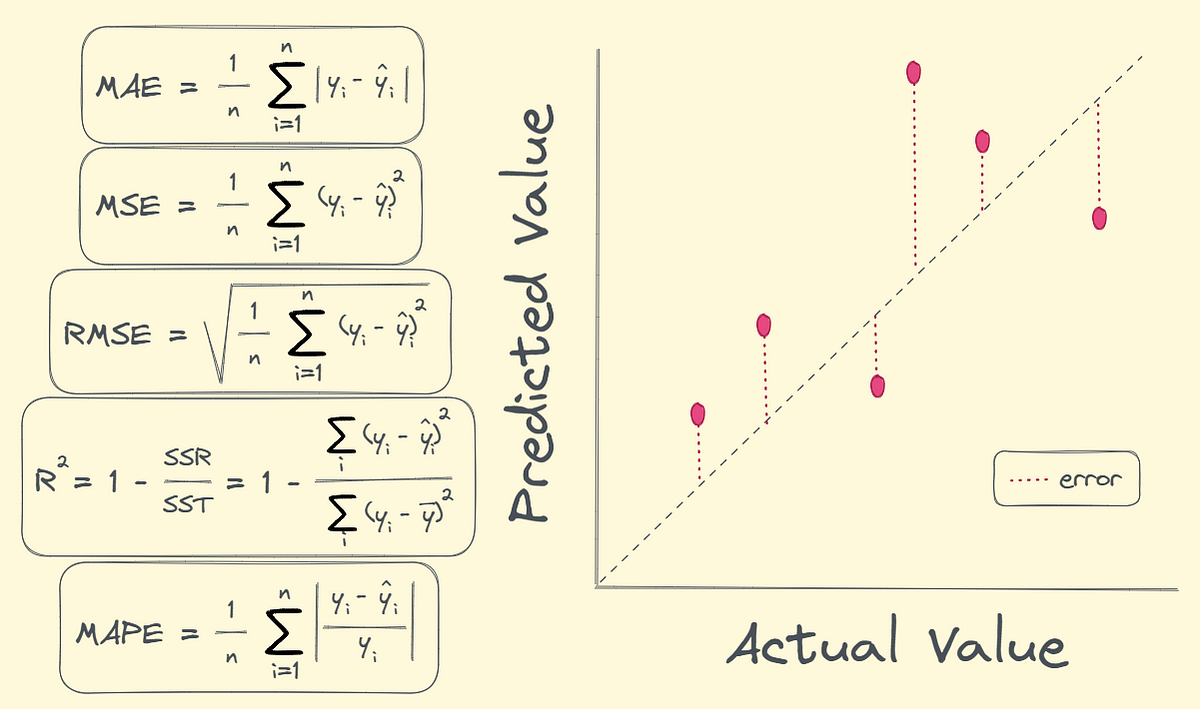

In [26]:
import sklearn.metrics as metrics

def compute_metrics(y_true, y_pred):
    mae = metrics.mean_absolute_error(y_true, y_pred)
    rmse = metrics.root_mean_squared_error(y_true, y_pred)
    mape = metrics.mean_absolute_percentage_error(y_true, y_pred)
    return {
        "mae": mae,
        "rmse": rmse,
        "mape": mape
    }

**[SOAL]** Lakukan perhitungan untuk semua hasil dari model tersebut, lalu tampilkan dalam suatu dataframe agar memudahkan pembacaan.

In [27]:
results = {}
for col in test_result.columns[1:]:
    results[col] = compute_metrics(test['Monthly soda production'], test_result[col])

pd.DataFrame(results).T

,mae,rmse,mape
avg_3,1.912917e+01,2.382459e+01,1.209630e-01
avg_6,2.070868e+01,2.547339e+01,1.302955e-01
avg_9,1.981296e+01,2.453253e+01,1.252408e-01
avg_12,1.698090e+01,2.097825e+01,1.076294e-01
AR,1.517377e+01,1.832671e+01,1.021543e-01
ARIMA,1.322850e+01,1.569449e+01,8.545764e-02
SARIMA,9.273436e+00,1.161212e+01,5.985257e-02
Prophet,5.929733e+18,5.963446e+18,3.911725e+16
LinearRegression_Tuned,3.713265e+01,4.213908e+01,2.588427e-01


**[SOAL]** Berikan interpretasi Anda terhadap hasil evaluasi tersebut. Manakah model yang memberikan performa terbaik?

Berdasarkan tabel evaluasi:

1. **Model terbaik: SARIMA**

   * **MAE** terendah (≈ 9.27), **RMSE** terendah (≈ 11.61), dan **MAPE** terendah (≈ 5.98 %)
   * Memodelkan komponen AR, differencing, MA, **dan** seasonal secara eksplisit (P,D,Q,m=12), sehingga akurasi jauh lebih baik pada data musiman.

2. **Progressi performa**

   * Pengambilan rata-rata sederhana (avg\_n) memberikan kesalahan terbesar, meski window 12 bulan sedikit lebih baik.
   * AR(12) memperbaiki dengan memanfaatkan korelasi 12-bulan sebelumnya.
   * ARIMA(12,1,1) menambahkan komponen differencing dan MA sehingga error makin turun.
   * SARIMA (AutoARIMA seasonal) akhirnya paling unggul dengan menangkap pola musiman tahunan dan tren jangka panjang.

3. **Model lain kurang cocok**

   * **Prophet** gagal fit (error sangat besar).
   * **Regresi linier** dengan tune-nya tidak lebih baik karena tidak mampu menangkap pola musiman kompleks dan non-linearitas deret waktu.



**[SOAL]** Bandingkan performa model AR dan ARIMA (dan AutoARIMA). Manakah yang lebih baik secara akurasi? Jelaskan alasannya mengapa bisa terjadi demikian menurut Anda.

**Perbandingan Performa**

| Model                  | MAE   | RMSE  | MAPE    |
| ---------------------- | ----- | ----- | ------- |
| **AR(12)**             | 15.17 | 18.33 | 10.22 % |
| **ARIMA(12,1,1)**      | 13.23 | 15.69 | 8.55 %  |
| **AutoARIMA (SARIMA)** | 9.27  | 11.61 | 5.99 %  |

1. **AR(12) vs ARIMA(12,1,1)**

   * **AR(12)** hanya menggunakan **komponen autoregressive**: prediksi bulan ini adalah kombinasi linier dari 12 nilai bulan sebelumnya. Ini sudah menangkap sebagian besar pola “musiman” karena deret sangat bergantung pada nilai setahun lalu, tapi **tidak** menangani:

     * **Trend** jangka panjang (kecenderungan naik-turun secara umum).
     * **Noise jangka pendek** (fluktuasi random).
   * **ARIMA(12,1,1)** menambahkan:

     * **Differencing** (d=1) untuk menghilangkan trend linear dan membuat seri lebih stasioner.
     * **MA(1)** untuk memodelkan error satu-periode sebelumnya, membantu meredam noise.
   * **Hasil**: ARIMA(12,1,1) menurunkan MAE dari 15.17 → 13.23 dan RMSE dari 18.33 → 15.69 karena ia bisa sekaligus menangani trend dan noise, bukan hanya autoregression.

2. **ARIMA(12,1,1) vs AutoARIMA (SARIMA)**

   * **ARIMA(12,1,1)** memperlakukan data seolah **tidak seasonal** (meski lag=12 ada, tapi tidak ada parameter seasonal P,D,Q khusus).
   * **AutoARIMA** (menghasilkan SARIMA) secara otomatis menemukan parameter
     $(p,d,q)$ **dan** $(P,D,Q)_\text{m=12}$, sehingga:

     * **Seasonal differencing** ($D=1$) menghilangkan pola musiman tahunan.
     * **Seasonal AR/MA** (P,Q) secara eksplisit menangkap sisa pola berulang tiap 12 bulan.
   * **Hasil**: MAE turun drastis lagi ke 9.27, RMSE ke 11.61, karena model seasonal jauh lebih akurat dalam merepresentasikan siklus tahunan kuat dalam data soda.

---

**Mengapa Bisa Terjadi Begitu?**

* **Trend**: AR(12) tidak menghilangkan kenaikan kumulatif jangka panjang → overshoot. Differencing di ARIMA membantu.
* **Noise and Lag Dependence**: MA komponent ARIMA menyeimbangkan error satu-periode → prediksi lebih halus.
* **Seasonality**: Pada data soda, pola musiman tahunan sangat dominan. SARIMA (AutoARIMA seasonal) secara eksplisit memodelkan siklus itu, sementara ARIMA “biasa” hanya mencoba meniru pola 12-lag tanpa membedakan komponen seasonal.

> **Intinya**:
>
> * **AR → ARIMA**: bertambah baik karena trend & noise ditangani.
> * **ARIMA → SARIMA**: bertambah baik lagi karena pola musim tahunan tertangani secara eksplisit.
>   Jadi, **AutoARIMA (SARIMA)** adalah yang paling akurat untuk data musiman bulanan ini.
